<a href="https://colab.research.google.com/github/proshenjitbarua06-dot/skill-morph/blob/main/revised_smart_grid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading Dataset...
Dataset Shape: (4000, 22)

Fault Severity Distribution:
Fault Severity
High      1777
Low       1771
Medium     452
Name: count, dtype: int64
Classes: ['High' 'Low' 'Medium']
Training samples: 3200, Test samples: 800
After SMOTE: 0    1777
1    1777
2    1777
Name: count, dtype: int64
Selected Features: ['Current Magnitude (A)', 'Active Power (kW)', 'Reactive Power (kVAR)', 'Load Demand (kW)', 'Frequency Variation (Hz)', 'Power Factor', 'Temperature Value (°C)', 'Wind Speed (m/s)', 'Solar Irradiance (W/m²)', 'Grid Stability Index', 'Line Loss (kW)', 'Renewable Contribution (%)']
Training Random Forest...
Training Extra Trees...
Training Gradient Boosting...
Training Voting Classifier...
Training Stacking Classifier...
Training SVM...
Training KNN...

=== MODEL PERFORMANCE ===
                 Model  Accuracy  Precision  Recall  F1-Weighted 

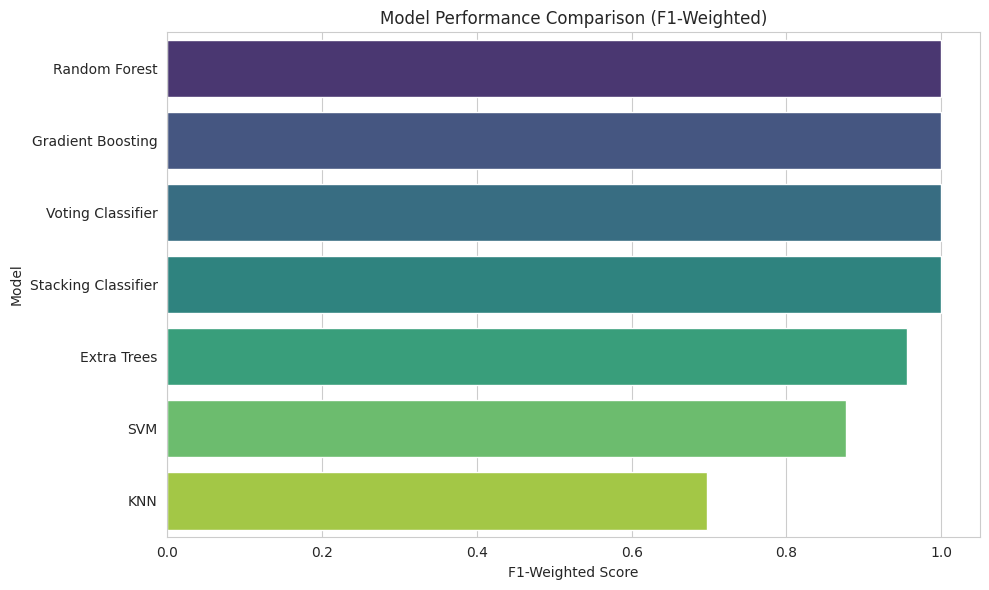

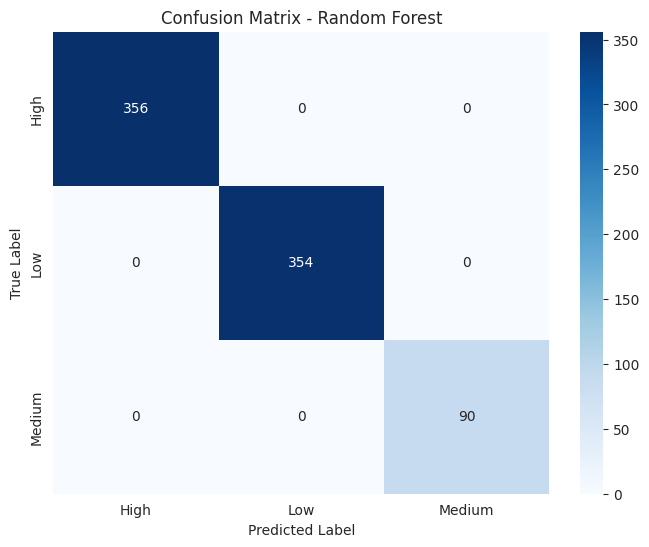

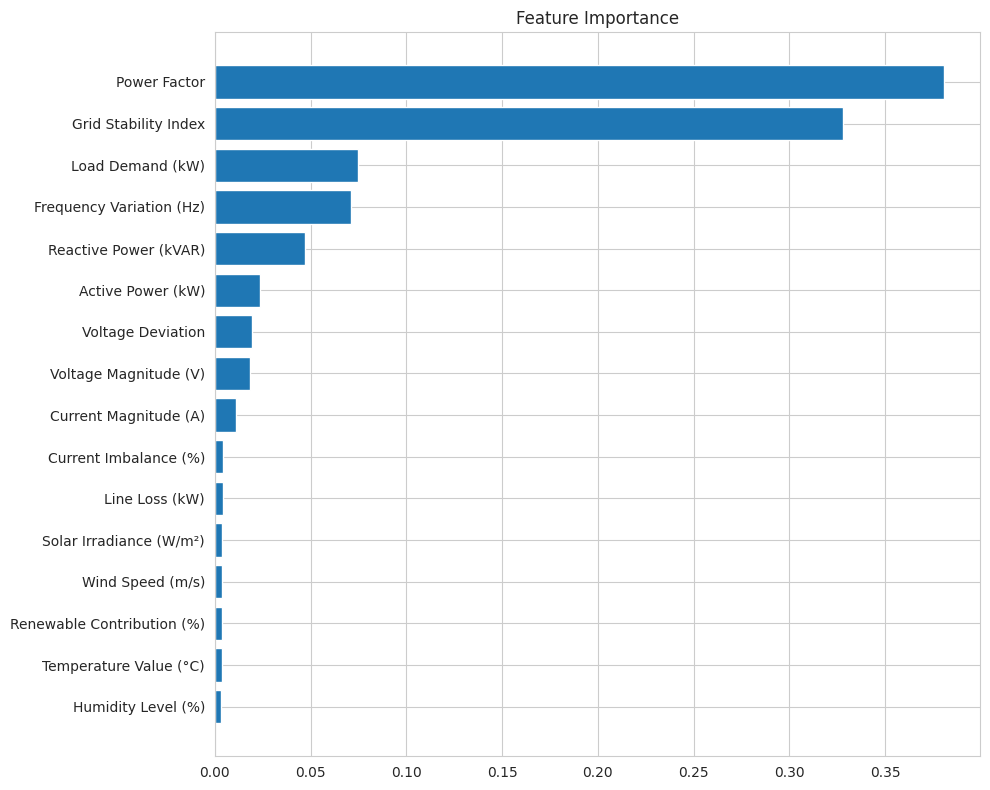

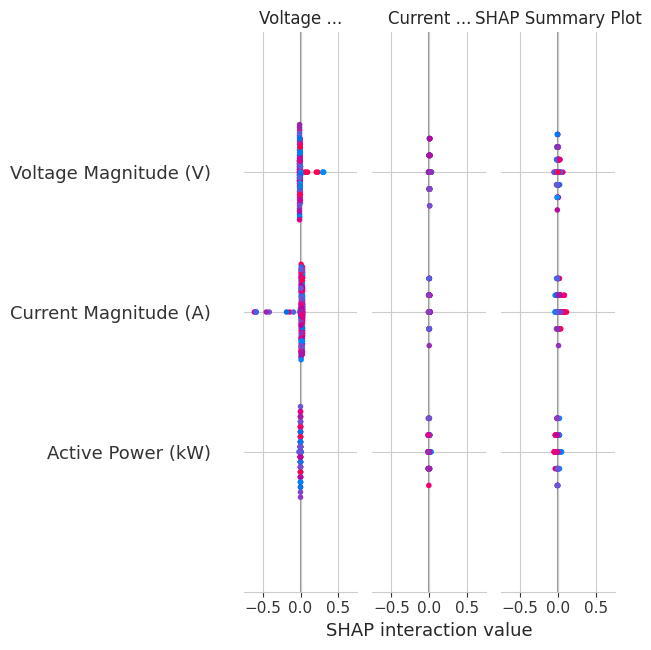


=== ROBUSTNESS ANALYSIS ===
Noise 0.000 → F1: 1.0000
Noise 0.030 → F1: 0.9750
Noise 0.060 → F1: 0.9637
Noise 0.090 → F1: 0.9487
Noise 0.120 → F1: 0.9525
Noise 0.150 → F1: 0.9224


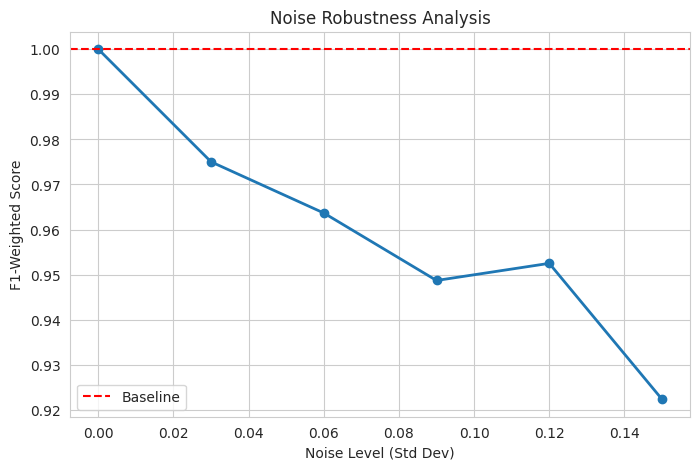


FINAL RESULTS TABLE (IEEE Style)
              Model  Accuracy  Precision  Recall  F1-Weighted    MCC  CV_F1_Mean  CV_F1_Std
      Random Forest    1.0000     1.0000  1.0000       1.0000 1.0000      0.9989     0.0012
  Gradient Boosting    1.0000     1.0000  1.0000       1.0000 1.0000      0.9989     0.0015
  Voting Classifier    1.0000     1.0000  1.0000       1.0000 1.0000      0.9992     0.0009
Stacking Classifier    1.0000     1.0000  1.0000       1.0000 1.0000      0.9992     0.0009
        Extra Trees    0.9562     0.9574  0.9562       0.9563 0.9271      0.9527     0.0085
                SVM    0.8775     0.8774  0.8775       0.8774 0.7933      0.9033     0.0111
                KNN    0.7075     0.7058  0.7075       0.6977 0.4954      0.7754     0.0168

Best Model: Random Forest with F1-Weighted = 1.0000

Results saved successfully!


In [23]:
# =============================================================================
# A ROBUST MACHINE LEARNING FRAMEWORK FOR SMART GRID POWER MONITORING
# Integrating Stratified K-Fold Validation and Ensemble Classifiers
# =============================================================================

from google.colab import drive
drive.mount('/content/drive')

# ========================== INSTALLATIONS ==========================
!pip install -q shap imbalanced-learn

# ========================== IMPORT LIBRARIES ==========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, learning_curve, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             confusion_matrix, roc_auc_score, matthews_corrcoef,
                             roc_curve, precision_recall_curve, average_precision_score,
                             classification_report)

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SelectKBest, f_classif

from scipy.stats import ttest_rel, wilcoxon
import numpy as np

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# ========================== 1. LOAD DATASET ==========================
print("Loading Dataset...")
df = pd.read_csv("/content/drive/MyDrive/Dataset/Smart Grid Power Monitoring Dataset.csv")

print(f"Dataset Shape: {df.shape}")
print("\nFault Severity Distribution:")
print(df['Fault Severity'].value_counts())

# ========================== 2. PREPROCESSING ==========================
le = LabelEncoder()
y = le.fit_transform(df['Fault Severity'])
print(f"Classes: {le.classes_}")

features = ['Voltage Magnitude (V)', 'Current Magnitude (A)', 'Active Power (kW)',
            'Reactive Power (kVAR)', 'Load Demand (kW)', 'Frequency Variation (Hz)',
            'Power Factor', 'Temperature Value (°C)', 'Humidity Level (%)',
            'Wind Speed (m/s)', 'Solar Irradiance (W/m²)', 'Grid Stability Index',
            'Voltage Deviation', 'Line Loss (kW)', 'Current Imbalance (%)',
            'Renewable Contribution (%)']

X = df[features].copy()

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test Split (Stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42)

print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

# ========================== 3. HANDLE CLASS IMBALANCE (SMOTE) ==========================
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_scaled, y)

print("After SMOTE:", pd.Series(y_res).value_counts())

# Feature Selection (Top 12 features)
selector = SelectKBest(score_func=f_classif, k=12)
X_selected = selector.fit_transform(X_res, y_res)
selected_features = [features[i] for i in selector.get_support(indices=True)]
print("Selected Features:", selected_features)

# ========================== 4. DEFINE MODELS ==========================
rf = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42, n_jobs=-1)
et = ExtraTreesClassifier(n_estimators=200, random_state=42, n_jobs=-1)
gb = GradientBoostingClassifier(random_state=42)
svm = SVC(probability=True, random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

voting = VotingClassifier(
    estimators=[('rf', rf), ('et', et), ('gb', gb)],
    voting='soft'
)

stacking = StackingClassifier(
    estimators=[('rf', rf), ('et', et), ('gb', gb)],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,
    stack_method='predict_proba'
)

models = {
    "Random Forest": rf,
    "Extra Trees": et,
    "Gradient Boosting": gb,
    "Voting Classifier": voting,
    "Stacking Classifier": stacking,
    "SVM": svm,
    "KNN": knn
}

# ========================== 5. MODEL EVALUATION ==========================
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

results = []

for name, model in models.items():
    print(f"Training {name}...")

    # Cross-validation
    cv_f1 = cross_val_score(model, X_res, y_res, cv=skf, scoring='f1_weighted', n_jobs=-1)

    # Fit on train
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "Recall": recall_score(y_test, y_pred, average='weighted'),
        "F1-Weighted": f1_score(y_test, y_pred, average='weighted'),
        "MCC": matthews_corrcoef(y_test, y_pred),
        "CV_F1_Mean": np.mean(cv_f1),
        "CV_F1_Std": np.std(cv_f1)
    }

    if y_prob is not None:
        metrics["ROC-AUC"] = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')
        metrics["PR-AUC"] = average_precision_score(y_test, y_prob, average='weighted')

    results.append(metrics)

results_df = pd.DataFrame(results).sort_values("F1-Weighted", ascending=False)
print("\n=== MODEL PERFORMANCE ===")
print(results_df.round(4))

# ========================== 6. STATISTICAL SIGNIFICANCE ==========================
best_model = models["Stacking Classifier"]   # or Random Forest
scores_stacking = cross_val_score(best_model, X_res, y_res, cv=skf, scoring='f1_weighted', n_jobs=-1)
scores_rf = cross_val_score(rf, X_res, y_res, cv=skf, scoring='f1_weighted', n_jobs=-1)

t_stat, p_t = ttest_rel(scores_stacking, scores_rf)
w_stat, p_w = wilcoxon(scores_stacking, scores_rf)

print(f"\nPaired t-test p-value: {p_t:.4f}")
print(f"Wilcoxon p-value: {p_w:.4f}")

# Cohen's d
diff = scores_stacking - scores_rf
cohen_d = np.mean(diff) / np.std(diff)
print(f"Cohen's d: {cohen_d:.4f}")

# ========================== 7. HYPERPARAMETER TUNING (Optional but Recommended) ==========================
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 15, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid,
                           cv=5, scoring='f1_weighted', n_jobs=-1)
grid_search.fit(X_train, y_train)
print("Best Params:", grid_search.best_params_)

# ========================== 8. VISUALIZATIONS ==========================

# 8.1 Performance Bar Plot
plt.figure(figsize=(10,6))
sns.barplot(data=results_df, x="F1-Weighted", y="Model", palette="viridis")
plt.title("Model Performance Comparison (F1-Weighted)")
plt.xlabel("F1-Weighted Score")
plt.tight_layout()
plt.show()

# 8.2 Confusion Matrix (Best Model)
best_name = results_df.iloc[0]["Model"]
best_model = models[best_name]
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred_best), annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f"Confusion Matrix - {best_name}")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# 8.3 Feature Importance (Random Forest)
rf.fit(X_res, y_res)
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,8))
plt.title("Feature Importance")
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 8.4 SHAP Explainability
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test[:100])  # Subsample for speed

shap.summary_plot(shap_values, X_test[:100], feature_names=features, show=False)
plt.title("SHAP Summary Plot")
plt.tight_layout()
plt.show()

# ========================== 9. ROBUSTNESS ANALYSIS ==========================
print("\n=== ROBUSTNESS ANALYSIS ===")
noise_levels = np.linspace(0, 0.15, 6)
f1_noisy = []

rf.fit(X_train, y_train)
baseline_f1 = f1_score(y_test, rf.predict(X_test), average='weighted')

for noise in noise_levels:
    X_noisy = X_test + np.random.normal(0, noise, X_test.shape)
    y_pred_noisy = rf.predict(X_noisy)
    f1 = f1_score(y_test, y_pred_noisy, average='weighted')
    f1_noisy.append(f1)
    print(f"Noise {noise:.3f} → F1: {f1:.4f}")

plt.figure(figsize=(8,5))
plt.plot(noise_levels, f1_noisy, marker='o', linewidth=2)
plt.axhline(baseline_f1, color='r', linestyle='--', label='Baseline')
plt.xlabel("Noise Level (Std Dev)")
plt.ylabel("F1-Weighted Score")
plt.title("Noise Robustness Analysis")
plt.legend()
plt.grid(True)
plt.show()

# ========================== 10. FINAL IEEE-STYLE TABLE ==========================
final_table = results_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Weighted',
                          'MCC', 'CV_F1_Mean', 'CV_F1_Std']].round(4)

print("\n" + "="*80)
print("FINAL RESULTS TABLE (IEEE Style)")
print("="*80)
print(final_table.to_string(index=False))
print(f"\nBest Model: {best_name} with F1-Weighted = {results_df.iloc[0]['F1-Weighted']:.4f}")

# Save results
results_df.to_csv("/content/drive/MyDrive/smart_grid_results.csv", index=False)
print("\nResults saved successfully!")